In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings



from sklearn.tree import _tree
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from collections import Counter

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform, pdist, cdist
from scipy.special import digamma

import dask.dataframe as dd
from dask.distributed import Client
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg




plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore')


In [91]:
# zadanie 1

def generate_credit_data(n_samples = 1000, n_features = 10, random_state = 42):
    X, y = make_classification(
        n_samples = n_samples, n_features = n_features,
        n_informative = 6, n_redundant = 2, n_clusters_per_class = 2,
        random_state = random_state
    )
    return X, y

def bootstrap_sample(X, y, random_state = None):
    rng = np.random.RandomState(random_state)
    n = len(X)
    indices = rng.choice(n, size=n, replace = True)
    oob_indices = list(set(range(n)) - set(indices))
    return X[indices], y[indices], oob_indices

def train_single_trees(X_train, y_train, n_trees = 10):
    trees = []
    for seed in range(n_trees):
        tree = DecisionTreeClassifier(random_state = seed)
        tree.fit(X_train, y_train)
        trees.append(tree)
    return trees

def calculate_prediction_variance(trees, X):
    """ oblicza wariancje predykcji miedzy drzewami """
    # TODO : zbierz predict_proba ze wszystkich drzew
    all_preds = np.array([tree.predict_proba(X)[:, 1] for tree in trees])
    # TODO : oblicz wariancje dla kazdego punktu
    variance = np.var(all_preds, axis=0)
    return variance


def ensemble_predict(trees, X):
    """ agreguje predykcje wielu drzew przez glosowanie wiekszosciowe """
    # TODO : zbierz predykcje ze wszystkich drzew
    # TODO : dla kazdego punktu zwroc najczesciej wysteujaca klase
    pass

def calculate_oob_error(X, y, trees, oob_indices_list):
    """ Oblicza OOB error bez zbioru walidacyjnego """
    # TODO : dla kazdego punktu uzyj tylko drzew, ktore go nie widziały
    # TODO : zaglosuj i porownaj z prawdziwa etykieta
    pass



Wytrenowano 10 drzew


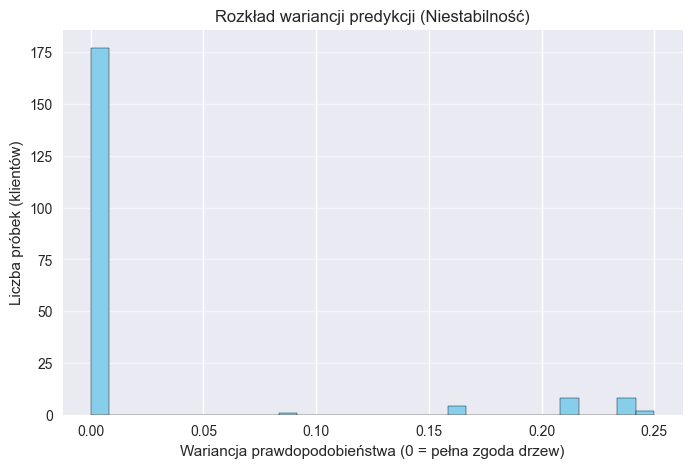

' te drzewka na prawo nie sa zgodne.\nokolice 0.25 to zagrozenie.\nbo:\nwariancja zmiennej binarnej jest najwieksza gdy szansa wynosi 50/50\nczyli dla tych klientow, polowa drzew daje kredyt, polowa nie.\nto jest to miejsce, gdy jest niestabilnosc decyzji.\n'

In [92]:
# a)
X, y = generate_credit_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
trees = train_single_trees(X_train, y_train, n_trees=10)
print(f'Wytrenowano {len(trees)} drzew')
variances = calculate_prediction_variance(trees, X_test)

def plot_variance_histogram(variances):
    plt.figure(figsize=(8, 5))
    plt.hist(variances, bins=30, color='skyblue', edgecolor='black')
    plt.title("Rozkład wariancji predykcji (Niestabilność)")
    plt.xlabel("Wariancja prawdopodobieństwa (0 = pełna zgoda drzew)")
    plt.ylabel("Liczba próbek (klientów)")
    plt.grid(axis='y', alpha=0.5)
    plt.show()

plot_variance_histogram(variances)


""" te drzewka na prawo nie sa zgodne.
okolice 0.25 to zagrozenie.
bo:
wariancja zmiennej binarnej jest najwieksza gdy szansa wynosi 50/50
czyli dla tych klientow, polowa drzew daje kredyt, polowa nie.
to jest to miejsce, gdy jest niestabilnosc decyzji.
"""

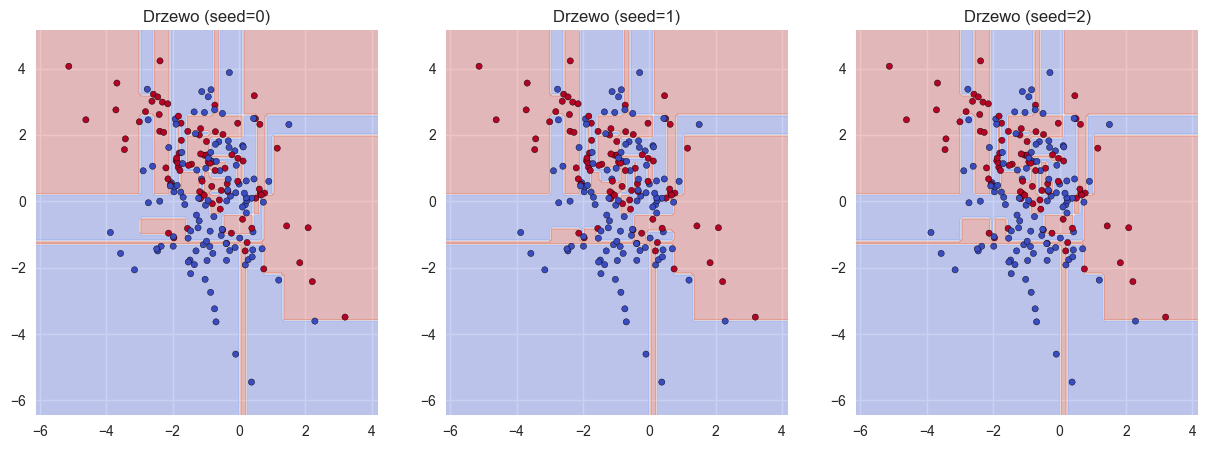

In [93]:
def plot_decision_boundaries_2d(X, y):
    # Wybieramy tylko dwie pierwsze cechy do wizualizacji
    X_2d = X[:, :2]

    # Trenujemy 3 drzewa na tych 2 cechach z różnymi seedami
    models = []
    for seed in [0, 1, 2]:
        clf = DecisionTreeClassifier(random_state=seed)
        clf.fit(X_2d, y)
        models.append(clf)

    # Przygotowanie siatki do rysowania (meshgrid)
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Rysowanie
    plt.figure(figsize=(15, 5))
    for i, model in enumerate(models):
        plt.subplot(1, 3, i + 1)

        # Predykcja dla każdego punktu siatki
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Rysowanie konturów (strefy decyzyjne)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

        # Rysowanie punktów danych
        plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', s=20, cmap='coolwarm')
        plt.title(f"Drzewo (seed={i})")

    plt.show()

# Uruchomienie wizualizacji
plot_decision_boundaries_2d(X_test, y_test)

In [94]:
# b)
def train_bootstrap_ensemble(X_train, y_train, n_trees = 50):
    trees = []
    for i in range(n_trees):
        X_boot, y_boot, _ = bootstrap_sample(X_train, y_train, random_state = i)
        tree = DecisionTreeClassifier(random_state=i)
        tree.fit(X_boot, y_boot)
        trees.append(tree)
    return trees

ensemble_trees = train_bootstrap_ensemble(X_train, y_train, n_trees=50)
print(f"W lesie mamy : {len(ensemble_trees)} drzew.")

W lesie mamy : 50 drzew.


In [95]:
def ensemble_predict(trees, X):
    all_preds = np.array([tree.predict(X) for tree in trees])
    avg_preds = np.mean(all_preds, axis = 0) # jesli srednia > 0.5 to wiekszosc glosowala za 1
    final_predictions = (avg_preds > 0.5).astype(int)
    return final_predictions

y_pred_ensemble = ensemble_predict(ensemble_trees, X_test)
acc = accuracy_score(y_test, y_pred_ensemble)
print(f"Accuracy calego zespolu : {acc:.4f}")

Accuracy calego zespolu : 0.8550


In [96]:
def cmp_with_a(ensemble_trees, X, single_tree_var):
    # ja podzieliem 50 zespolow na 5 teamow po 10
    n_ensembles = 5
    trees_per_ensemble = 10
    ensemble_predictions = []
    for i in range(n_ensembles):
        sub_ensemble = ensemble_trees[i*trees_per_ensemble : (i+1)*trees_per_ensemble]
        sub_preds = np.array([tree.predict_proba(X)[:, 1] for tree in sub_ensemble])
        ensemble_mean_pred = np.mean(sub_preds, axis = 0)
        ensemble_predictions.append(ensemble_mean_pred)

    # wariancja miedzy teamami
    ensemble_variance = np.var(np.array(ensemble_predictions), axis = 0)

    # porownanie
    mean_var_single = np.mean(single_tree_var) # (a)
    mean_var_ensemble = np.mean(ensemble_variance) # (b)

    print(f"Wariancja (a) : {mean_var_single:.6f}")
    print(f"Wariancja (b) : {mean_var_ensemble:.6f}")

ensemble_vars = cmp_with_a(ensemble_trees, X_test, variances)

Wariancja (a) : 0.024150
Wariancja (b) : 0.008196


In [97]:
# c)
def train_random_forest(X_train, y_train, n_trees = 50):
    """
    trenujemy las. kazdy drzewo:
    -> uczy sie na probce bootstrap
    -> przy kazdym podziale widzi tylko sqrt(p) cech
    """

    trees = []
    for i in range(n_trees):
        X_boot, y_boot, _ = bootstrap_sample(X_train, y_train, random_state=i)
        tree = DecisionTreeClassifier(
            max_features = 'sqrt',
            random_state = i
        )
        tree.fit(X_boot, y_boot)
        trees.append(tree)
    return trees

forest_trees = train_random_forest(X_train, y_train, n_trees = 50)
print(f"Las ma {len(forest_trees)} drzew")

Las ma 50 drzew


In [98]:
# bagging : kazde drzewo widzialo inne dane, ale wszystkie cechy
# random forest : kazde drzewo widzialo inne dane i losowy podzbior cech

"""
dlaczego korelacja jest istotna?
jesli korelacja jest niska, to beldy jednego drzewa sa naprawiane przez inne.
gdy korelacja jest wysoka, to drzewa sa prawie identyczne.
jesli jedno sie pomyli to wszystkie sie pomylą.

Random Forest powinien miec niższa srednia korelacje niz Bagging
"""


def calculate_mean_correlation(trees, X):
    # pobieramy predykcje dla kazdego drzewa
    # shape : (liczba_drzew, liczba_probek)
    probs = np.array([tree.predict_proba(X)[:, 1] for tree in trees])
    # macierz korelacji
    corr_matrix = np.corrcoef(probs)
    # srednia z wartosci poza przekatna
    n = corr_matrix.shape[0]
    sum_corr = np.sum(corr_matrix) - n # jedynki z przekatnej
    mean_corr = sum_corr / (n*(n-1)) # suma / liczba par
    return mean_corr

# porownanie
corr_bagging = calculate_mean_correlation(ensemble_trees, X_test)
corr_rf = calculate_mean_correlation(forest_trees, X_test)

print(f"Srednia korelacja dla baggingu : {corr_bagging:.4f}")
print(f"Srednia korelacja dla RF : {corr_rf:.4f}")

Srednia korelacja dla baggingu : 0.6089
Srednia korelacja dla RF : 0.5374


In [99]:
# zadanie 2

def generate_network_data(n_normal = 950, n_anomaly = 50, random_state = 42):
    """ generuje dane ruchu sieciowego z anomaliami """
    np.random.seed(random_state)
    # normalny ruch - 3 klastry operacyjne
    normal = np.vstack([
        np.random.randn(n_normal//3, 4) * 0.5 + [50, 100, 0.8, 30],
        np.random.randn(n_normal//3, 4) * 0.5 + [55, 110, 0.75, 35],
        np.random.randn(n_normal//3, 4) * 0.5 + [48, 95, 0.85, 28]
    ])
    # anomalie - rozne wzorce atakow
    anomalies = np.vstack([
        np.random.randn(n_anomaly//2, 4) * 0.3 + [200, 500, 0.1, 5],
            # DDOS
        np.random.randn(n_anomaly//2, 4) * 0.3 + [10, 10, 0.99, 100]
            # Port scan
    ])
    X = np.vstack([normal, anomalies])
    y = np.array([0] * len(normal) + [1] * len(anomalies))
    return X, y

class IsolationTree:
    """Pojedyncze drzewo izolujace."""
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, current_depth=0):
        """Buduje drzewo z losowymi podzialami."""
        n_samples, n_features = X.shape

        # Warunek stopu:
        # - Jeśli został 1 punkt (izolacja zakończona)
        # - Jeśli osiągnięto max_depth
        if n_samples <= 1 or (self.max_depth and current_depth >= self.max_depth):
            return {
                'type': 'leaf',
                'size': n_samples,
                'depth': current_depth
            }

        # Losujemy cechę
        feature = np.random.randint(0, n_features)

        # Sprawdzamy zakres wartości dla tej cechy
        min_val, max_val = X[:, feature].min(), X[:, feature].max()

        # Zabezpieczenie przed nieskończoną pętlą (gdy wszystkie punkty są identyczne w tej cesze)
        if min_val == max_val:
            return {'type': 'leaf', 'size': n_samples, 'depth': current_depth}

        # Losujemy próg
        threshold = np.random.uniform(min_val, max_val)

        # Dzielimy dane
        left_mask = X[:, feature] < threshold
        right_mask = ~left_mask

        # Budujemy rekurencyjnie
        return {
            'type': 'node',
            'feature': feature,
            'threshold': threshold,
            'left': self.fit(X[left_mask], current_depth + 1),
            'right': self.fit(X[right_mask], current_depth + 1)
        }

    def train(self, X):
        """Helper do uruchomienia treningu."""
        self.root = self.fit(X)
        return self

    def path_length(self, x, node=None, current_depth=0):
        """Oblicza glebokosc izolacji punktu x."""
        if node is None:
            node = self.root


        if node['type'] == 'leaf':
            return current_depth


        if x[node['feature']] < node['threshold']:
            return self.path_length(x, node['left'], current_depth + 1)
        else:
            return self.path_length(x, node['right'], current_depth + 1)

def c_factor(n):
    if n <= 1:
        return 0
    return 2 * (np.log(n-1) + 0.5772156649) - 2*(n-1) / n

def anomaly_score(path_lengths, n_samples):
    """ oblicza znormalizowany anomaly score. """
    c = c_factor(n_samples)
    return 2 ** (-np.array(path_lengths) / c)





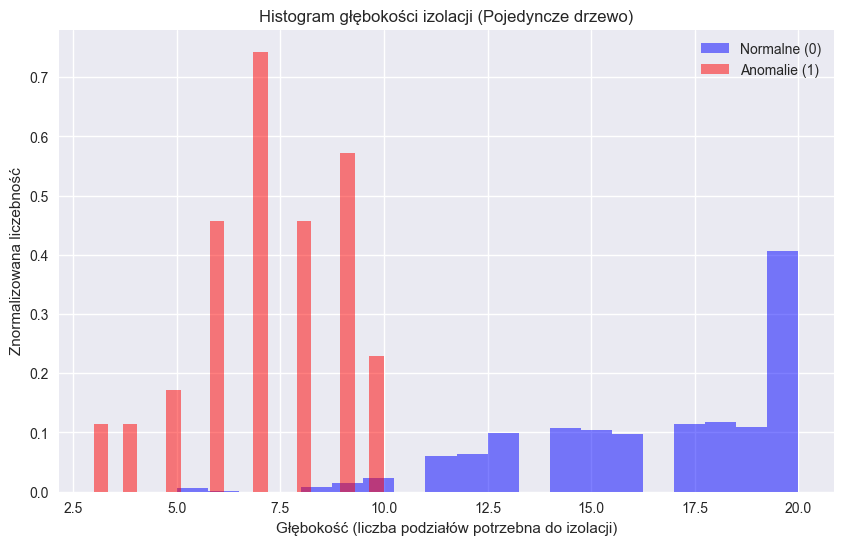

In [100]:
X_net, y_net = generate_network_data()

iso_tree = IsolationTree(max_depth=20)
iso_tree.train(X_net)

# Obliczanie długości ścieżki dla każdego punktu
depths = np.array([iso_tree.path_length(x) for x in X_net])

plt.figure(figsize=(10, 6))
plt.hist(depths[y_net==0], bins=20, alpha=0.5, label='Normalne (0)', density=True, color='blue')
plt.hist(depths[y_net==1], bins=20, alpha=0.5, label='Anomalie (1)', density=True, color='red')
plt.title("Histogram głębokości izolacji (Pojedyncze drzewo)")
plt.xlabel("Głębokość (liczba podziałów potrzebna do izolacji)")
plt.ylabel("Znormalizowana liczebność")
plt.legend()
plt.show()

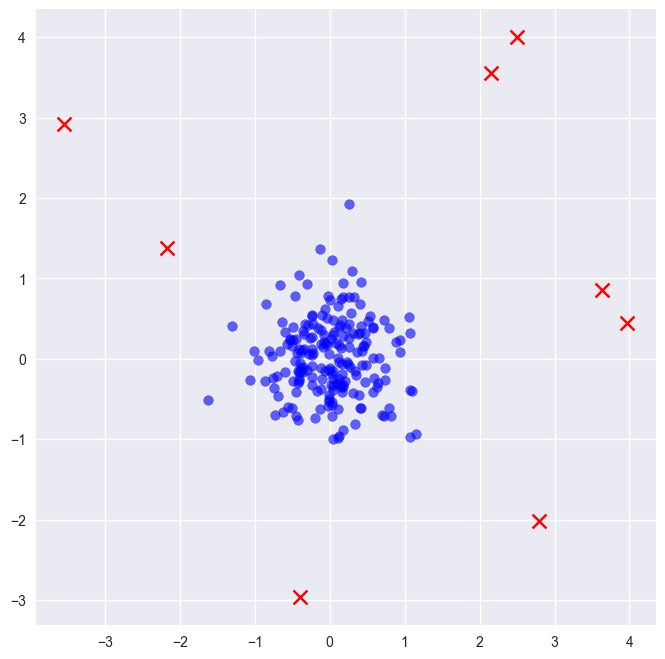

In [101]:
# b)

def generate_2d_geometric_data(n_normal=200, n_anomaly=10):
    """Generuje proste dane 2D do wizualizacji geometrycznej."""
    np.random.seed(42)

    X_normal = np.random.randn(n_normal, 2) * 0.5


    X_anomalies = np.random.uniform(-4, 4, (n_anomaly, 2))

    X_anomalies = X_anomalies[np.abs(X_anomalies).max(axis=1) > 2]

    X = np.vstack([X_normal, X_anomalies])
    y = np.array([0]*len(X_normal) + [1]*len(X_anomalies))

    return X, y

def plot_tree_splits(node, x_min, x_max, y_min, y_max, ax):
    if node['type'] == 'leaf':
        return

    if node['feature'] == 0:
        ax.vlines(node['threshold'], y_min, y_max, colors='k', linestyles='-', linewidth=0.5, alpha=0.7)
        plot_tree_splits(node['left'], x_min, node['threshold'], y_min, y_max, ax)
        plot_tree_splits(node['right'], node['threshold'], x_max, y_min, y_max, ax)

    else:
        ax.hlines(node['threshold'], x_min, x_max, colors='k', linestyles='-', linewidth=0.5, alpha=0.7)
        plot_tree_splits(node['left'], x_min, x_max, y_min, node['threshold'], ax)
        plot_tree_splits(node['right'], x_min, x_max, node['threshold'], y_max, ax)


X_geo, y_geo = generate_2d_geometric_data()


iso_tree_vis = IsolationTree(max_depth=10)
iso_tree_vis.train(X_geo)


fig, ax = plt.subplots(figsize=(8, 8))


ax.scatter(X_geo[y_geo==0][:, 0], X_geo[y_geo==0][:, 1], c='blue', label='Normalne', alpha=0.6)
ax.scatter(X_geo[y_geo==1][:, 0], X_geo[y_geo==1][:, 1], c='red', label='Anomalie', s=100, marker='x')


In [102]:
def train_isolation_forest(X, n_trees=100, sub_sample_size=256):
    """
    Trenuje las izolujący.
    Wazne: Kazde drzewo trenujemy na malej podprobce (sub_sample_size)!
    To przyspiesza dzialanie i zwieksza roznorodnosc (jak bagging).
    """
    trees = []
    n_samples = X.shape[0]

    for i in range(n_trees):
        # Losujemy indeksy
        indices = np.random.choice(n_samples, size=min(n_samples, sub_sample_size), replace=False)
        X_sub = X[indices]

        # Trenujemy drzewo
        tree = IsolationTree(max_depth=np.ceil(np.log2(sub_sample_size))) # Optymalna glebokosc to log2(n)
        tree.train(X_sub)
        trees.append(tree)

    return trees

def get_ensemble_scores(trees, X, sub_sample_size=256):
    """
    1. Przepuszcza dane przez wszystkie drzewa.
    2. Liczy srednia dlugosc sciezki E[h(x)].
    3. Zamienia ja na anomaly score.
    """
    paths = np.array([[tree.path_length(x) for x in X] for tree in trees])

    mean_paths = paths.mean(axis=0)


    scores = anomaly_score(mean_paths, sub_sample_size)
    return scores

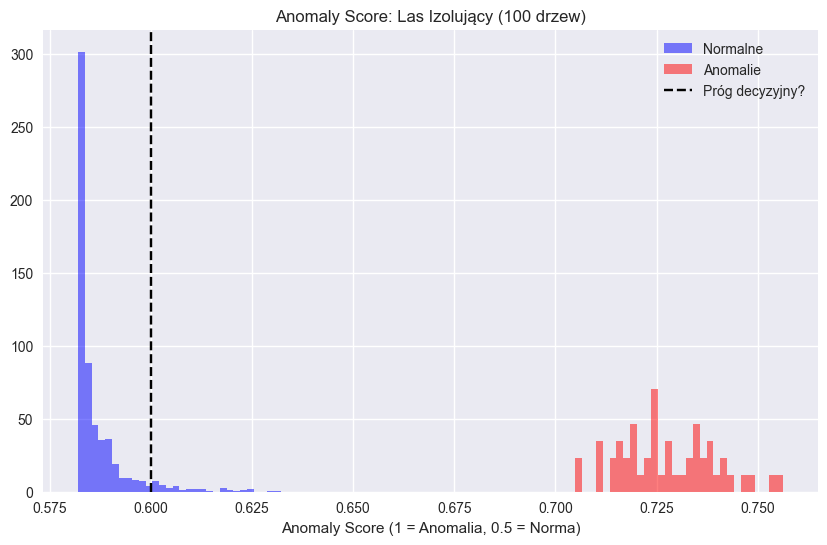

In [103]:
forest = train_isolation_forest(X_net, n_trees=100, sub_sample_size=256)
scores = get_ensemble_scores(forest, X_net, sub_sample_size=256)

plt.figure(figsize=(10, 6))
plt.hist(scores[y_net==0], bins=30, alpha=0.5, label='Normalne', density=True, color='blue')
plt.hist(scores[y_net==1], bins=30, alpha=0.5, label='Anomalie', density=True, color='red')
plt.axvline(x=0.6, color='k', linestyle='--', label='Próg decyzyjny?')
plt.title("Anomaly Score: Las Izolujący (100 drzew)")
plt.xlabel("Anomaly Score (1 = Anomalia, 0.5 = Norma)")
plt.legend()
plt.show()

In [104]:
# d)

def evaluate_model(y_true, y_pred, model_name):
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)

threshold = 0.6
my_preds = (scores > threshold).astype(int)

evaluate_model(y_net, my_preds, "Custom Isolation Forest")

contamination = 0.05

iso_sk = IsolationForest(contamination=contamination, random_state=42)
preds_iso = iso_sk.fit_predict(X_net)

preds_iso_binary = (preds_iso == -1).astype(int)
evaluate_model(y_net, preds_iso_binary, "Sklearn Isolation Forest")

lof = LocalOutlierFactor(contamination=contamination)
preds_lof = lof.fit_predict(X_net)
preds_lof_binary = (preds_lof == -1).astype(int)
evaluate_model(y_net, preds_lof_binary, "Local Outlier Factor (LOF)")

oc_svm = OneClassSVM(nu=contamination)
preds_svm = oc_svm.fit_predict(X_net)
preds_svm_binary = (preds_svm == -1).astype(int)
evaluate_model(y_net, preds_svm_binary, "One-Class SVM")

--- Custom Isolation Forest ---
Precision: 0.4630
Recall:    1.0000
F1 Score:  0.6329
------------------------------
--- Sklearn Isolation Forest ---
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
------------------------------
--- Local Outlier Factor (LOF) ---
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------
--- One-Class SVM ---
Precision: 0.5526
Recall:    0.4200
F1 Score:  0.4773
------------------------------


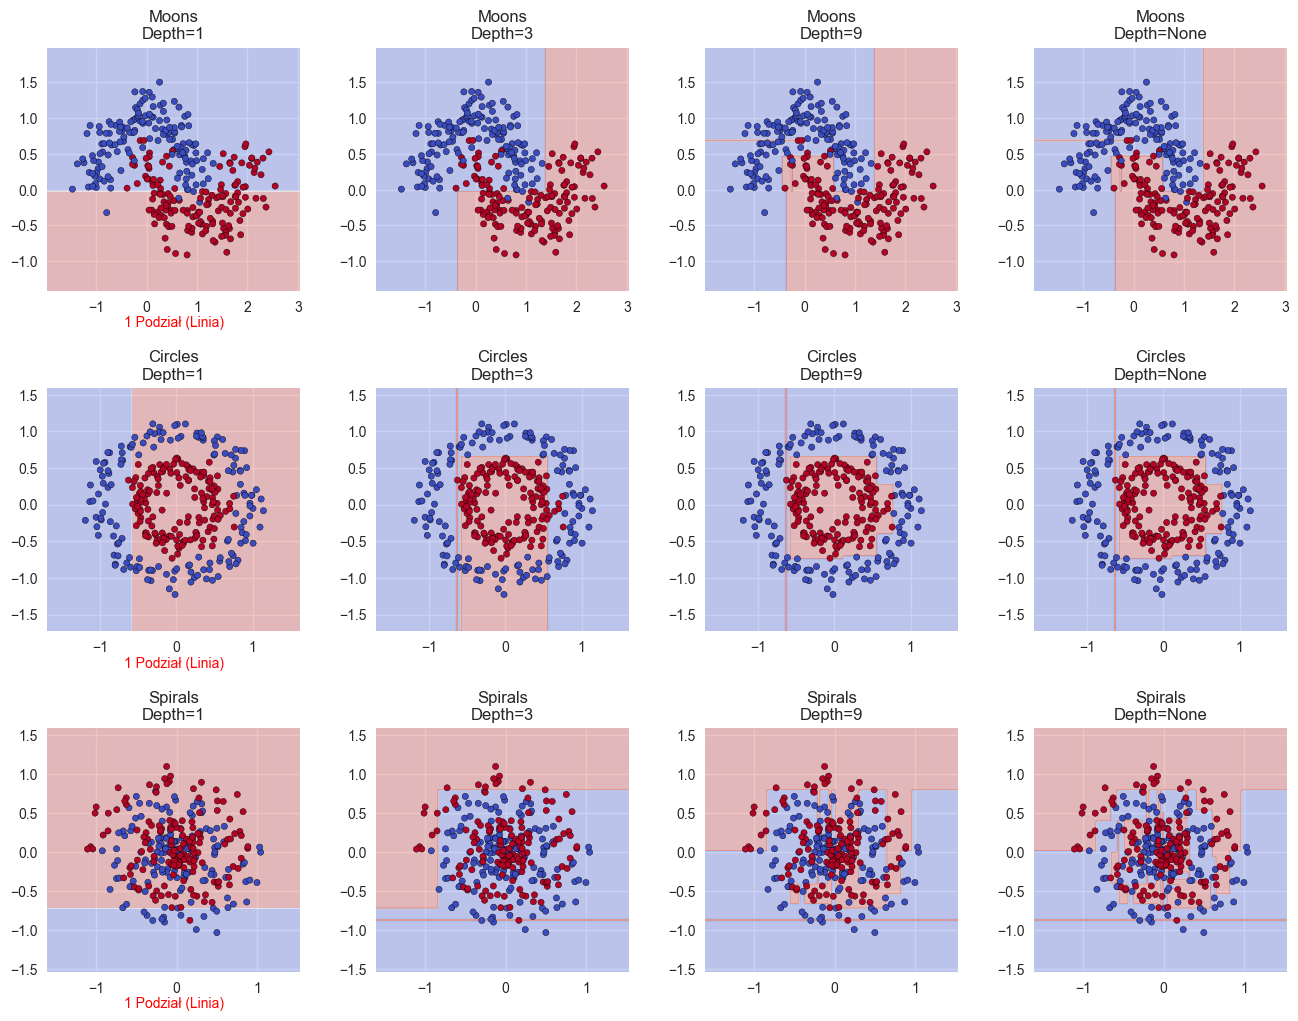

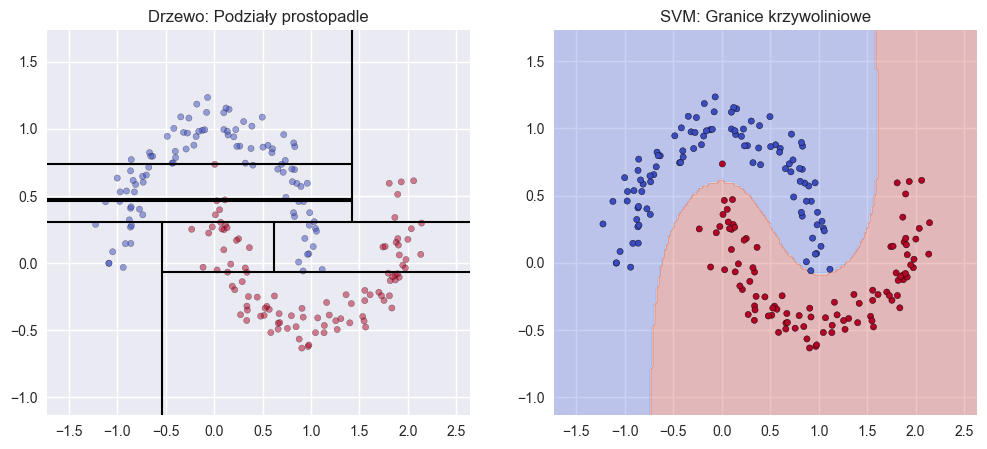

Error <= 0.1. potrzebne podzialy = 3.
Error <= 0.05. potrzebne podzialy = 4.
Error <= 0.02. potrzebne podzialy = 4.
Error <= 0.01. potrzebne podzialy = 4.


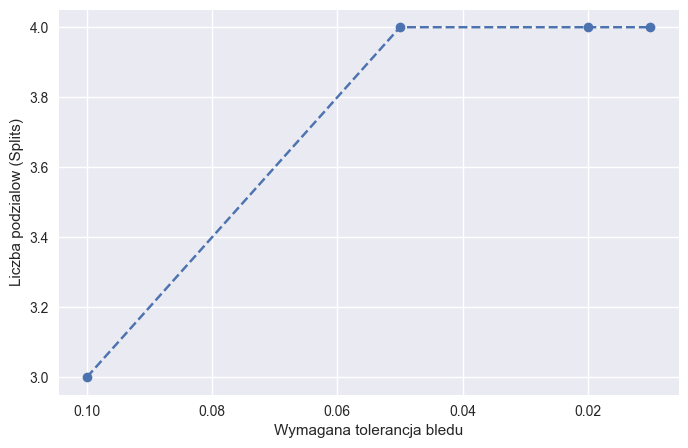

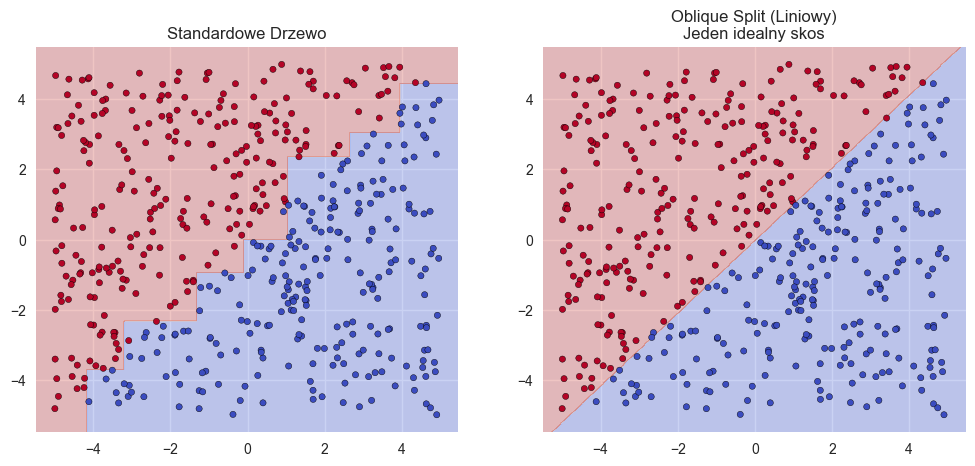

In [ ]:
def make_spirals(n_samples=500, noise=0.1, random_state=42):
    np.random.seed(random_state)
    n = n_samples // 2
    theta = np.linspace(0, 4 * np.pi, n)
    r = theta / (4 * np.pi)


    x1 = (r * np.cos(theta)) + np.random.randn(n) * noise
    y1 = (r * np.sin(theta)) + np.random.randn(n) * noise
    x2 = -(r * np.cos(theta)) + np.random.randn(n) * noise
    y2 = -(r * np.sin(theta)) + np.random.randn(n) * noise

    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.array([0] * n + [1] * n)
    return X, y

def plot_decision_boundary(model, X, y, ax, title=""):

    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    if hasattr(model, "predict"):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=20)
    ax.set_title(title)



def run_task_a():


    datasets = [
        ("Moons", make_moons(n_samples=300, noise=0.2, random_state=42)),
        ("Circles", make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)),
        ("Spirals", make_spirals(n_samples=300, noise=0.1))
    ]


    depths = [1, 3, 9, None] # None -> brak limitu (overfitting)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, (ds_name, (X, y)) in enumerate(datasets):
        for j, depth in enumerate(depths):
            ax = axes[i, j]

            # Trenujemy drzewo
            clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
            clf.fit(X, y)

            plot_decision_boundary(clf, X, y, ax, f"{ds_name}\nDepth={depth}")

            if depth == 1:
                ax.text(0.5, -0.15, "1 Podział (Linia)", transform=ax.transAxes, ha='center', color='red')

    plt.show()


def visualize_tree_splits(tree, X, y, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20, alpha=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    def recurse(node_id, r_x_min, r_x_max, r_y_min, r_y_max):
        feature = tree.tree_.feature[node_id]
        threshold = tree.tree_.threshold[node_id]

        if feature == _tree.TREE_UNDEFINED:
            return


        if feature == 0:
            ax.plot([threshold, threshold], [r_y_min, r_y_max], 'k-', lw=1.5)
            recurse(tree.tree_.children_left[node_id], r_x_min, threshold, r_y_min, r_y_max)
            recurse(tree.tree_.children_right[node_id], threshold, r_x_max, r_y_min, r_y_max)

        else:
            ax.plot([r_x_min, r_x_max], [threshold, threshold], 'k-', lw=1.5)
            recurse(tree.tree_.children_left[node_id], r_x_min, r_x_max, r_y_min, threshold)
            recurse(tree.tree_.children_right[node_id], r_x_min, r_x_max, threshold, r_y_max)

    recurse(0, x_min, x_max, y_min, y_max)

def run_task_b():
    X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    tree = DecisionTreeClassifier(max_depth=4, random_state=42)
    tree.fit(X, y)
    visualize_tree_splits(tree, X, y, axes[0])
    axes[0].set_title("Drzewo: Podziały prostopadle")

    svm = SVC(kernel='rbf', C=1.0)
    svm.fit(X, y)
    plot_decision_boundary(svm, X, y, axes[1], "SVM: Granice krzywoliniowe")

    plt.show()

def count_splits_for_circle(radius, tolerance):
    X, y = make_circles(n_samples=2000, noise=0.0, factor=0.5, random_state=42)
    X = X * radius # Skalowanie

    for max_leaves in range(2, 500):
        clf = DecisionTreeClassifier(max_leaf_nodes=max_leaves, random_state=42)
        clf.fit(X, y)

        # error := (1 - accuracy)
        error = 1.0 - clf.score(X, y)

        if error <= tolerance:
            return max_leaves - 1

    return 500

def run_task_c():
    tolerances = [0.1, 0.05, 0.02, 0.01] # np. 0.01 to 99% dokładności
    results = []

    for tol in tolerances:
        n = count_splits_for_circle(radius=1, tolerance=tol)
        results.append(n)
        print(f"Error <= {tol}. potrzebne podzialy = {n}.")

    plt.figure(figsize=(8, 5))
    plt.plot(tolerances, results, marker='o', linestyle='--')
    plt.gca().invert_xaxis() # Oś X: od duzej do malej tolerancji (w prawo trudniej)
    plt.xlabel("Wymagana tolerancja bledu")
    plt.ylabel("Liczba podzialow (Splits)")
    plt.grid(True)
    plt.show()


def run_task_d():
    X = np.random.uniform(-5, 5, (500, 2))
    # y > x
    y = (X[:, 1] > X[:, 0]).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    tree = DecisionTreeClassifier(max_depth=5)
    tree.fit(X, y)
    plot_decision_boundary(tree, X, y, axes[0], "Standardowe Drzewo")

    oblique = LogisticRegression()
    oblique.fit(X, y)
    plot_decision_boundary(oblique, X, y, axes[1], "Oblique Split (Liniowy)\nJeden idealny skos")

    plt.show()



run_task_a()
run_task_b()
run_task_c()
run_task_d()